<a href="https://colab.research.google.com/github/dranphphmithe-ux/Book-Rental-System-Project/blob/main/%E0%B8%A3%E0%B8%A7%E0%B8%A1%E0%B9%82%E0%B8%84%E0%B9%89%E0%B8%94%E0%B8%AA%E0%B9%88%E0%B8%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ส่วนใหม่

In [ ]:
import os
import csv
import io
import ssl
from datetime import date
from urllib.request import Request, urlopen
from datetime import date, datetime
import random
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 2. นำฟอนต์เข้าสู่ระบบของ Matplotlib
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

# ฟังก์ชันที่ 1: คำนวณวันกำหนดส่ง (มี parameter, มี return)
def calculate_due_date(start_date_str: str, duration_days: int) -> str:
    """คำนวณวันกำหนดส่งคืนจากวันที่เริ่มเช่าและจำนวนวัน"""
    start_date_obj = datetime.strptime(start_date_str, "%Y-%m-%d %H:%M:%S")
    due_date_obj = start_date_obj + timedelta(days=duration_days)
    return due_date_obj.strftime("%Y-%m-%d")


# ฟังก์ชันที่ 2: จัดรูปแบบราคา (มี parameter, มี return)
def format_currency(amount: float) -> str:
    """จัดรูปแบบตัวเลขเป็นข้อความสกุลเงิน บาท"""
    return f"{amount:,.2f} บาท"


# ฟังก์ชันที่ 3: ตรวจสอบระดับลูกค้า (มี default argument, parameter, return)
def get_customer_level(points: int, status: str = "ปกติ") -> str:
    """ตรวจสอบระดับลูกค้าจากแต้มและสถานะ (default status='ปกติ')"""
    if status == "ระงับ":
        return "ไม่มีระดับ (ระงับ)"
    if points >= 500:
        return "Platinum"
    if points >= 200:
        return "Gold"
    if points >= 50:
        return "Silver"
    return "Member"

# ==================================================
# (จากนั้นตามด้วย class Customer ... จนจบโค้ดเดิม)
# ==================================================

#ขอ'กร
# ==================================================
# 1. ระบบจัดการสมาชิก (Customer & CustomerManager)
# ==================================================
class Customer:
    """คลาสสำหรับเก็บข้อมูลสมาชิกหน้าร้าน"""
    def __init__(self,name: str,customer_id: str,phone: str,email: str = "",points: int = 0,register_date: str = None,status: str = "ปกติ",):
        self.name = name
        self.customer_id = customer_id
        self.phone = phone  # เบอร์โทรหลักสำหรับค้นหา
        self.email = email
        self.points = points
        self.register_date = register_date or str(date.today())
        self.status = status

    def add_points(self, amount: int):
        """เพิ่มแต้มเมื่อทำรายการเช่าหน้าร้านสำเร็จ"""
        self.points += amount
        print(
            f"  [ระบบแต้ม] เพิ่มให้คุณ {self.name} +{amount} แต้ม (สะสมรวม:"
            f" {self.points} แต้ม)"
        )

    def update_info(
        self, name: str = None, phone: str = None, email: str = None
    ):
        """พนักงานแก้ไขข้อมูลให้ลูกค้าหน้าร้าน"""
        if name:
            self.name = name
        if phone:
            self.phone = phone
        if email:
            self.email = email
        print(f"  [อัปเดตข้อมูล] แก้ไขข้อมูลของคุณ {self.name} เรียบร้อย")


class CustomerManager:
    """ระบบจัดการสมาชิกหน้าร้านสำหรับพนักงาน"""

    def __init__(self):
        # เก็บข้อมูลโดยใช้ 'เบอร์โทร' เป็น Key เพื่อให้ค้นหาไวที่สุด
        self.customers_db = {}
        self.last_id_number = 0

    def register_customer(self, name: str, phone: str, email: str = ""):
        """พนักงานกดเพิ่มสมาชิกใหม่"""
        # 1. ตรวจสอบเบอร์โทรซ้ำ
        if phone in self.customers_db:
            print(f"❌ ไม่สามารถสมัครได้: เบอร์โทร {phone} เป็นสมาชิกอยู่แล้ว!")
            return self.customers_db[phone]

        # 2. รันรหัสสมาชิกให้อัตโนมัติ (เช่น CUST001, CUST002)
        self.last_id_number += 1
        new_id = f"CUST{self.last_id_number:03d}"

        # 3. สร้าง Object Customer
        new_customer = Customer(
            name=name,
            customer_id=new_id,
            phone=phone,
            email=email,
            points=0,  # สมาชิกใหม่เริ่มที่ 0 แต้ม
        )

        # 4. บันทึกลงระบบ
        self.customers_db[phone] = new_customer
        print(
            f"✅ สมัครสำเร็จ! [รหัส: {new_id} | ชื่อ: {name} | เบอร์: {phone} |"
            f" วันที่: {new_customer.register_date}]"
        )
        return new_customer

    def find_customer_by_phone(self, phone: str):
        """พนักงานค้นหาสมาชิกด้วยเบอร์โทรตอนลูกค้ามาเช่าหนังสือ"""
        customer = self.customers_db.get(phone)
        if customer:
            print(
                f"🔍 พบข้อมูล: คุณ{customer.name} (รหัส: {customer.customer_id}"
                f" | แต้ม: {customer.points})"
            )
            return customer
        else:
            print(f"❌ ไม่พบข้อมูลสมาชิกจากเบอร์โทร: {phone}")
            return None


In [ ]:
import csv
import io
import ssl
from urllib.request import Request, urlopen

#ของกวาง
# ==================================================
# 1. Class Book (โครงสร้างข้อมูลหนังสือ)
# ==================================================
class Book:
    """คลาสสำหรับเก็บข้อมูลหนังสือการ์ตูนแต่ละเล่ม"""

    def __init__(
        self,
        book_isbn: str,
        title: str,
        author: str,
        price: str | float,
        category_id: str,
        sub_category_id: str,
        shelf_location: str,
        stock_qty: str | int,
    ):
        self.book_isbn = str(book_isbn).strip()
        self.title = str(title).strip()
        self.author = str(author).strip()

        try:
            self.price = float(price) if price else 0.0
        except ValueError:
            self.price = 0.0

        try:
            self.stock_qty = int(stock_qty) if stock_qty else 0
        except ValueError:
            self.stock_qty = 0

        self.category_id = str(category_id).strip()
        self.sub_category_id = str(sub_category_id).strip()
        self.shelf_location = str(shelf_location).strip()

    @property
    def status(self) -> str:
        """สถานะการเช่า: ถ้าสต็อก > 0 เป็น 'พร้อมเช่า' ถ้าสต็อก <= 0 เป็น 'สินค้าหมด'"""
        return "พร้อมเช่า" if self.stock_qty > 0 else "สินค้าหมด"

    def is_available(self) -> bool:
        return self.stock_qty > 0

    def decrease_stock(self, qty: int = 1) -> bool:
        if self.stock_qty >= qty:
            self.stock_qty -= qty
            return True
        return False

    def increase_stock(self, qty: int = 1):
        self.stock_qty += qty



In [ ]:
#ของตุ
# ==================================================
# 2. Class BookCatalogManager (ค้นหาและแสดงผล UI ตาราง)
# ==================================================
class BookCatalogManager:
    """ระบบคลังหนังสือหน้าร้าน พร้อมหน้าจอแสดงผลค้นหาแบบตาราง"""

import csv

# 1.นิยาม Class
class BookSearch:

    def __init__(self, filepath: str):
        self.catalog = []
        self.load_data(filepath)

    def load_data(self, filepath: str):
        try:
            with open(filepath, mode="r", encoding="utf-8-sig") as f:
                reader = csv.DictReader(f)
                self.catalog = [row for row in reader]
            print(
                "ระบบพร้อมใช้งาน: โหลดข้อมูลหนังสือเรียบร้อย"
                f" {len(self.catalog)} รายการ\n"
            )
        except Exception as e:
            print(f"เกิดข้อผิดพลาดในการโหลดไฟล์ CSV: {e}\n")

    def search_by_title(self, keyword: str):
        print(f"ผลการค้นหาชื่อหนังสือ: '{keyword}'")
        results = [
            b
            for b in self.catalog
            if keyword.lower() in b.get("title", "").lower()
        ]
        self._show_results(results)

    def search_by_isbn(self, isbn_code: str):
        print(f"ผลการค้นหารหัส/ISBN: '{isbn_code}'")
        results = [
            b
            for b in self.catalog
            if isbn_code.lower() in b.get("book_isbn", "").lower()
        ]
        self._show_results(results)

    def _show_results(self, results: list):
        if not results:
            print("ไม่พบข้อมูลหนังสือที่คุณต้องการค้นหา\n")
            return

        print(f"พบรายการหนังสือทั้งหมด {len(results)} รายการ")
        print("┌" + "─" * 76 + "┐")

        for i, b in enumerate(results, 1):
            isbn = b.get("book_isbn", "-")
            title = b.get("title", "-")
            author = b.get("author", "-")
            price = b.get("price", "-")
            shelf = b.get("shelf_location", "-")
            stock = b.get("stock_qty", "-")

            print(f"  [{i:02d}] {title}")
            print(
                f"       ISBN: {isbn:<14} ผู้แต่ง: {author:<22} ชั้นวาง:"
                f" {shelf}"
            )
            print(
                f"       ราคา: {price:>5} บาท             จำนวนคงเหลือ:"
                f" {stock} เล่ม"
            )

            if i < len(results):
                print("  " + "┈" * 36)

        print("└" + "─" * 76 + "┘\n")


In [5]:
class Receipt:   #ของน้ำหวาน
    """คลาสคำนวณเงินและออกใบเสร็จ (ปรับโปรโมชั่นเป็น: แถมวันยืมเพิ่มฟรี)"""

    import pandas as pd
import random
from datetime import datetime

# 1. โหลดข้อมูลจาก CSV
url = 'https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv'
df_books = pd.read_csv(url)
df_books.columns = df_books.columns.str.strip()

# ตรวจสอบและแปลงคอลัมน์สต็อกให้เป็นตัวเลข
stock_col = 'stock_qty' if 'stock_qty' in df_books.columns else 'stock'
df_books[stock_col] = pd.to_numeric(df_books[stock_col], errors='coerce').fillna(10).astype(int)

# รายชื่อลูกค้า
FIRST_NAMES = ["กิตติพงษ์", "ณิชา", "ธนกฤต", "ปรียา", "พงศกร", "ภัทรวดี", "วรวุฒิ", "ศิริพร", "อัครพล", "อนันดา"]
LAST_NAMES = ["ใจดี", "เจริญสุข", "สมบูรณ์", "วงษ์สุวรรณ", "รัตนไพศาล", "พงษ์พาณิชย์", "ชินวัตร", "ทองแท้", "สุวรรณรัตน์", "มั่นคง"]

# ==========================================
# ฟังก์ชัน 1: ยืมหนังสือ (ตัดสต็อก + ออกใบเสร็จ)
# ==========================================
def rent_books_and_print_receipt(customer_name, customer_id, initial_points, selected_indices, days_rented, days_late):
    global df_books

    order_id = f"REC-{datetime.now().strftime('%Y%m%d')}-{random.randint(1000, 9999)}"
    date_issued = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    items = []
    # ตัดสต็อกในคลังข้อมูล
    for idx in selected_indices:
        title = df_books.loc[idx, 'title'] if 'title' in df_books.columns else df_books.loc[idx, 'name']
        price = float(df_books.loc[idx, 'price'])

        current_stock = df_books.loc[idx, stock_col]
        new_stock = max(0, current_stock - 1)
        df_books.loc[idx, stock_col] = new_stock

        items.append({
            'title': title,
            'price': price,
            'remaining_stock': new_stock
        })

    total_books = len(items)

    # คำนวณค่ายืม (3 วัน 20 บาท, เศษวันละ 7 บาท)
    sets_of_3 = days_rented // 3
    remaining_days = days_rented % 3
    rental_fee_per_book = (sets_of_3 * 20) + (remaining_days * 7)
    total_rental_before_discount = total_books * rental_fee_per_book

    # แต้มและส่วนลด (ยืม 1 เล่ม = 1 แต้ม, คืนตรงเวลา +1 แต้ม)
    base_points = total_books
    on_time_bonus = 1 if days_late == 0 else 0
    earned_points = base_points + on_time_bonus
    total_points_accumulated = initial_points + earned_points

    # ครบ 10 แต้ม ได้อ่านฟรี 1 วัน (ลด 7 บาท/เล่ม)
    free_books_count = min(total_points_accumulated // 10, total_books)
    total_discount = free_books_count * 7.0

    # ค่าปรับและสรุปยอด
    total_rental_fee = max(0.0, total_rental_before_discount - total_discount)
    total_fine = total_books * days_late * 10
    grand_total = total_rental_fee + total_fine

    points_used = free_books_count * 10
    final_points = total_points_accumulated - points_used

    # พิมพ์ใบเสร็จยืม
    print("=" * 60)
    print(f"{'ใบเสร็จรับเงิน (ยืมหนังสือ) / Rental Receipt':^60}")
    print("=" * 60)
    print(f"เลขที่ใบเสร็จ: {order_id}")
    print(f"วันที่ทำรายการ: {date_issued}")
    print(f"ชื่อลูกค้า: {customer_name} (ID: {customer_id})")
    print(f"จำนวนวันที่ยืม: {days_rented} วัน | คืนช้า: {days_late} วัน")
    print("-" * 60)

    print(f"รายการหนังสือที่ยืม ({total_books} เล่ม):")
    for i, item in enumerate(items, 1):
        print(f"  [{i:02d}] {item['title']} (ราคาปก {item['price']:.0f} บาท) | 📦 สต็อกหลังหัก: {item['remaining_stock']} เล่ม")

    print("-" * 60)
    print(f"อัตราค่ายืมปกติต่อเล่ม ({days_rented} วัน): {rental_fee_per_book:.2f} บาท")

    if free_books_count > 0:
        print(f"🎁 ส่วนลดสะสมแต้ม (ครบ 10 แต้ม): อ่านฟรี 1 วัน จำนวน {free_books_count} เล่ม (-{total_discount:.2f} บาท)")

    print(f"รวมค่ายืมหนังสือหลังหักส่วนลด: {total_rental_fee:.2f} บาท")

    if total_fine > 0:
        print(f"❌ ค่าปรับคืนช้า ({days_late} วัน x {total_books} เล่ม x 10B): {total_fine:.2f} บาท")

    print("-" * 60)
    print(f"ยอดชำระสุทธิ (Grand Total): {grand_total:.2f} บาท")
    print("-" * 60)

    print(f"✨ แต้มที่ได้รับจากจำนวนหนังสือ (1 เล่ม = 1 แต้ม): +{base_points} แต้ม")
    if days_late == 0:
        print(f"🎉 โบนัสคืนตรงเวลา: +{on_time_bonus} แต้ม")
    else:
        print("🚫 คืนช้ากว่ากำหนด: ไม่ได้รับโบนัสคืนตรงเวลา (+0 แต้ม)")

    if points_used > 0:
        print(f"🔄 ใช้แต้มแลกอ่านฟรี: -{points_used} แต้ม")

    print(f"🏆 แต้มสะสมคงเหลือปัจจุบัน: {final_points} แต้ม")
    print("=" * 60 + "\n")

# ==========================================
# ฟังก์ชัน 2: คืนหนังสือ (บวกสต็อกกลับเข้าคลัง)
# ==========================================
def return_books_and_update_stock(customer_name, customer_id, returned_indices):
    global df_books

    return_id = f"RET-{datetime.now().strftime('%Y%m%d')}-{random.randint(1000, 9999)}"
    date_returned = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    returned_items = []
    # บวกสต็อกกลับเข้าคลังข้อมูล
    for idx in returned_indices:
        title = df_books.loc[idx, 'title'] if 'title' in df_books.columns else df_books.loc[idx, 'name']

        current_stock = df_books.loc[idx, stock_col]
        new_stock = current_stock + 1
        df_books.loc[idx, stock_col] = new_stock

        returned_items.append({
            'title': title,
            'restocked_qty': new_stock
        })

    # พิมพ์ใบคืนหนังสือ
    print("=" * 60)
    print(f"{'ใบคืนหนังสือ / Return Slip':^60}")
    print("=" * 60)
    print(f"เลขที่รายการคืน: {return_id}")
    print(f"วันที่ทำรายการคืน: {date_returned}")
    print(f"ชื่อลูกค้า: {customer_name} (ID: {customer_id})")
    print("-" * 60)

    print(f"รายการหนังสือที่รับคืน ({len(returned_items)} เล่ม):")
    for i, item in enumerate(returned_items, 1):
        print(f"  [{i:02d}] {item['title']} | 📥 อัปเดตสต็อกคืนคลังแล้ว: {item['restocked_qty']} เล่ม")

    print("-" * 60)
    print("✅ ทำรายการรับคืนหนังสือและคืนสต็อกสำเร็จ")
    print("=" * 60 + "\n")


# ==========================================
# ตัวอย่างการทำงาน (ยืม -> ตัดสต็อก -> คืน -> บวกสต็อกกลับ)
# ==========================================
customer_name = f"{random.choice(FIRST_NAMES)} {random.choice(LAST_NAMES)}"
customer_id = f"C{random.randint(100, 999)}"

# 1. เลือกหนังสือที่ต้องการยืม
available_books = df_books[df_books[stock_col] > 0]
selected_indices = available_books.sample(n=2).index.tolist()

# 2. ทำรายการยืม (ตัดสต็อก)
rent_books_and_print_receipt(
    customer_name=customer_name,
    customer_id=customer_id,
    initial_points=8,
    selected_indices=selected_indices,
    days_rented=3,
    days_late=0
)

# 3. ทำรายการคืน (บวกสต็อกกลับเข้าคลังเหมือนเดิม)
return_books_and_update_stock(
    customer_name=customer_name,
    customer_id=customer_id,
    returned_indices=selected_indices
)


        ใบเสร็จรับเงิน (ยืมหนังสือ) / Rental Receipt        
เลขที่ใบเสร็จ: REC-20260830-1724
วันที่ทำรายการ: 2026-08-30 08:44:55
ชื่อลูกค้า: กิตติพงษ์ วงษ์สุวรรณ (ID: C858)
จำนวนวันที่ยืม: 3 วัน | คืนช้า: 0 วัน
------------------------------------------------------------
รายการหนังสือที่ยืม (2 เล่ม):
  [01] ล่าขุมทรัพย์สุดขอบฟ้า เล่ม 42 (ราคาปก 165 บาท) | 📦 สต็อกหลังหัก: 4 เล่ม
  [02] มหาเวทย์ผนึกมาร (Jujutsu Kaisen) เล่ม 24 (ราคาปก 90 บาท) | 📦 สต็อกหลังหัก: 4 เล่ม
------------------------------------------------------------
อัตราค่ายืมปกติต่อเล่ม (3 วัน): 20.00 บาท
🎁 ส่วนลดสะสมแต้ม (ครบ 10 แต้ม): อ่านฟรี 1 วัน จำนวน 1 เล่ม (-7.00 บาท)
รวมค่ายืมหนังสือหลังหักส่วนลด: 33.00 บาท
------------------------------------------------------------
ยอดชำระสุทธิ (Grand Total): 33.00 บาท
------------------------------------------------------------
✨ แต้มที่ได้รับจากจำนวนหนังสือ (1 เล่ม = 1 แต้ม): +2 แต้ม
🎉 โบนัสคืนตรงเวลา: +1 แต้ม
🔄 ใช้แต้มแลกอ่านฟรี: -10 แต้ม
🏆 แต้มสะสมคงเหลือปัจจุบัน: 1 แต้ม

    

In [ ]:
import sqlite3

#ของดิว
# ==================================================
# [ส่วนที่นำไปต่อท้าย] ระบบบันทึกข้อมูล SQLite Database
# ==================================================
class DatabaseManager:
    """จัดการฐานข้อมูล SQLite สำหรับบันทึกสมาชิก หนังสือ และใบเสร็จ"""

    def __init__(self, db_name="comic_pos.db"):
        self.db_name = db_name
        self.init_db()

    def get_conn(self):
        return sqlite3.connect(self.db_name)

    def init_db(self):
        """สร้างตารางใน Database หากยังไม่มี"""
        with self.get_conn() as conn:
            cursor = conn.cursor()
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS customers (
                    customer_id TEXT PRIMARY KEY, name TEXT, phone TEXT UNIQUE,
                    email TEXT, points INTEGER, register_date TEXT, status TEXT
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS books (
                    book_isbn TEXT PRIMARY KEY, title TEXT, author TEXT,
                    price REAL, category_id TEXT, sub_category_id TEXT,
                    shelf_location TEXT, stock_qty INTEGER
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS receipts (
                    order_id TEXT PRIMARY KEY, customer_id TEXT, days_rented INTEGER,
                    days_late INTEGER, grand_total REAL, points_used INTEGER,
                    earned_points INTEGER, date_issued TEXT
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS receipt_items (
                    order_id TEXT, book_isbn TEXT
                )
            """
            )
            conn.commit()

    def save_customer(self, cust):
        """บันทึก หรือ อัปเดตข้อมูลสมาชิก"""
        with self.get_conn() as conn:
            conn.execute(
                """
                INSERT INTO customers VALUES (?, ?, ?, ?, ?, ?, ?)
                ON CONFLICT(customer_id) DO UPDATE SET
                    name=excluded.name, phone=excluded.phone, email=excluded.email,
                    points=excluded.points, status=excluded.status
            """,
                (
                    cust.customer_id,
                    cust.name,
                    cust.phone,
                    cust.email,
                    cust.points,
                    cust.register_date,
                    cust.status,
                ),
            )
            conn.commit()

    def save_books_from_catalog(self, catalog: list):
        """บันทึกรายการหนังสือทั้งหมดจากคลังลง Database"""
        with self.get_conn() as conn:
            for b in catalog:
                conn.execute(
                    """
                    INSERT INTO books VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                    ON CONFLICT(book_isbn) DO UPDATE SET
                        title=excluded.title, author=excluded.author, price=excluded.price, stock_qty=excluded.stock_qty
                """,
                    (
                        b.book_isbn,
                        b.title,
                        b.author,
                        b.price,
                        b.category_id,
                        b.sub_category_id,
                        b.shelf_location,
                        b.stock_qty,
                    ),
                )
            conn.commit()

    def save_receipt(self, receipt):
        """บันทึกใบเสร็จ อัปเดตแต้มสมาชิก และตัดสต็อกหนังสือใน DB"""
        calc = receipt.calculate_totals()
        with self.get_conn() as conn:
            # 1. บันทึกหัวใบเสร็จ
            conn.execute(
                """
                INSERT INTO receipts VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
                (
                    receipt.order_id,
                    receipt.customer.customer_id,
                    receipt.days_rented,
                    receipt.days_late,
                    calc["grand_total"],
                    calc["points_used"],
                    calc["earned_points"],
                    receipt.date_issued,
                ),
            )

            # 2. บันทึกรายการหนังสือที่ยืม + ตัดสต็อกใน DB
            for item in receipt.items:
                conn.execute(
                    "INSERT INTO receipt_items VALUES (?, ?)",
                    (receipt.order_id, item.book_isbn),
                )
                conn.execute(
                    "UPDATE books SET stock_qty = ? WHERE book_isbn = ?",
                    (item.stock_qty, item.book_isbn),
                )

            # 3. อัปเดตแต้มสมาชิกคงเหลือล่าสุดใน DB
            conn.execute(
                "UPDATE customers SET points = ? WHERE customer_id = ?",
                (receipt.customer.points, receipt.customer.customer_id),
            )
            conn.commit()
        print(f"💾 [DB] บันทึกใบเสร็จเลขที่ {receipt.order_id} ลง Database เรียบร้อย!")


✅ โหลดข้อมูลหนังสือสำเร็จ: 606 รายการ
✅ จำลองข้อมูลและบันทึกลง SQLite ครบ 300 รายการเรียบร้อย!

✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!



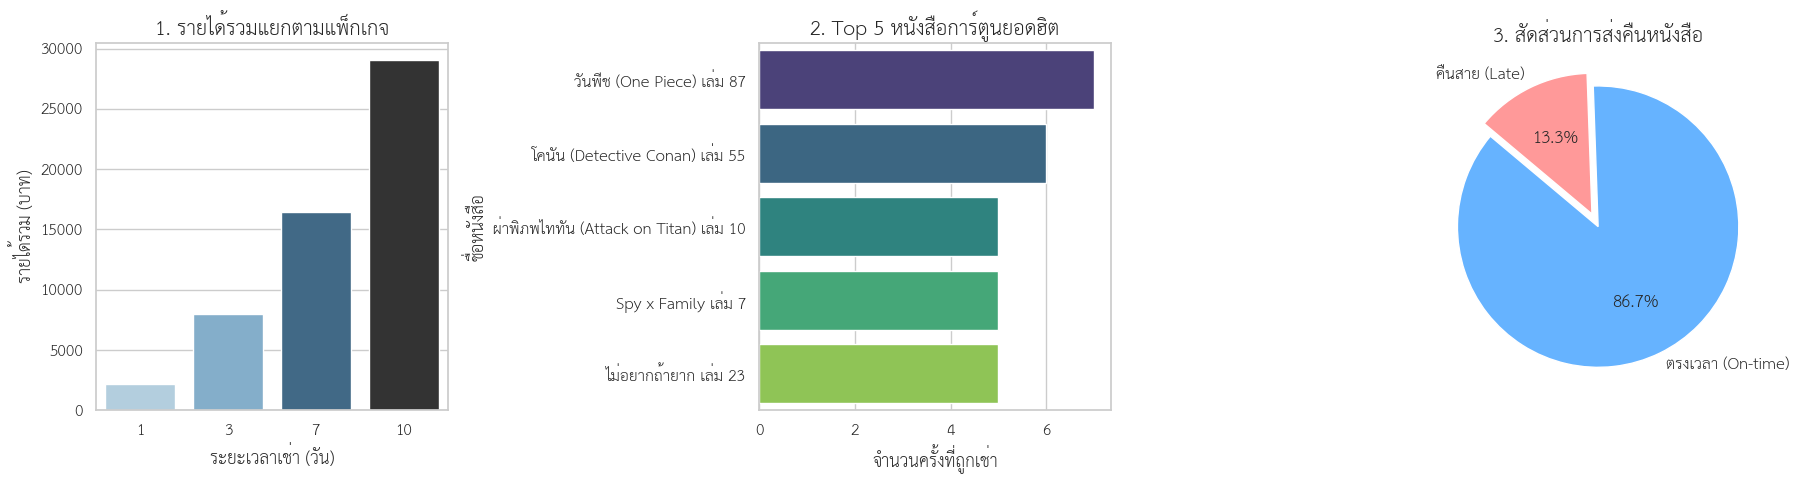

In [ ]:
def run_simulation_and_analysis():
    # --- เพิ่ม 2 บรรทัดนี้เพื่อล้างฐานข้อมูลเก่าก่อนรันใหม่เสมอ ---
    if os.path.exists("comic_pos.db"):
        os.remove("comic_pos.db")

    db = DatabaseManager("comic_pos.db")
    cust_mgr = CustomerManager()

    # 1. โหลดข้อมูลหนังสือจาก CSV จริง
    csv_url = "https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv"
    catalog_mgr = BookCatalogManager(csv_url)
    db.save_books_from_catalog(catalog_mgr.catalog)

    # 2. จำลองสร้างสมาชิก 30 คน
    for i in range(1, 31):
        c = cust_mgr.register_customer(
            name=f"Customer_{i:02d}",
            phone=f"081000{i:04d}",
            email=f"user{i}@email.com",
        )
        db.save_customer(c)

    # 3. จำลองสร้าง 300 ออเดอร์
    successful_orders = 0
    order_counter = 1

    while successful_orders < 300:
        random_phone = f"081000{random.randint(1, 30):04d}"
        customer = cust_mgr.find_customer_by_phone(random_phone)

        available_books = [b for b in catalog_mgr.catalog if b.is_available()]

        if not available_books:
            for b in catalog_mgr.catalog:
                b.stock_qty += 10
            available_books = catalog_mgr.catalog

        selected_books = random.sample(
            available_books, k=min(random.randint(1, 4), len(available_books))
        )
        days_rented = random.choice([1, 3, 7, 10])
        days_late = (
            random.choice([0, 0, 0, 1, 2]) if random.random() < 0.25 else 0
        )

        receipt = Receipt(
            order_id=f"REC{order_counter:05d}",
            customer=customer,
            items=selected_books,
            days_rented=days_rented,
            days_late=days_late,
        )

        db.save_receipt(receipt)
        successful_orders += 1
        order_counter += 1

    print(
        f"✅ จำลองข้อมูลและบันทึกลง SQLite ครบ {successful_orders} รายการเรียบร้อย!\n"
    )

    # =================================================================
    # 4. วิเคราะห์ข้อมูลด้วย SQL Query & Pandas (ตามเกณฑ์ Deliverable 3)
    # =================================================================
    conn = db.get_conn()

    # 4.1 SQL Query (GROUP BY + aggregate + ORDER BY)
    sql_q1 = pd.read_sql_query(
        """
        SELECT days_rented AS 'ระยะเวลาเช่า (วัน)',
               COUNT(order_id) AS 'จำนวนออเดอร์',
               SUM(grand_total) AS 'รายได้รวม (บาท)'
        FROM receipts
        GROUP BY days_rented
        ORDER BY SUM(grand_total) DESC
    """,
        conn,
    )

    # 4.2 SQL Query (JOIN หลายตาราง)
    sql_q2 = pd.read_sql_query(
        """
        SELECT b.title AS 'ชื่อหนังสือ',
               COUNT(ri.order_id) AS 'จำนวนครั้งที่ถูกเช่า'
        FROM receipt_items ri
        JOIN books b ON ri.book_isbn = b.book_isbn
        JOIN receipts r ON ri.order_id = r.order_id
        GROUP BY b.book_isbn, b.title
        ORDER BY COUNT(ri.order_id) DESC
        LIMIT 5
    """,
        conn,
    )

    # 4.3 Pandas Analysis (groupby / agg / sort_values)
    df_receipts = pd.read_sql_query("SELECT * FROM receipts", conn)
    df_customers = pd.read_sql_query("SELECT * FROM customers", conn)
    df_merged = df_receipts.merge(df_customers, on="customer_id")

    # วิเคราะห์ยอดใช้จ่ายรวมของลูกค้าแต่ละคนด้วย Pandas
    pandas_analysis = df_merged.groupby("name").agg(
        total_spent=("grand_total", "sum"),
        rent_count=("order_id", "count")
    ).sort_values("total_spent", ascending=False).head(5).reset_index()

    # =================================================================
    # 5. Export ข้อมูลเป็นไฟล์ CSV (ตามเกณฑ์ Deliverable 2)
    # =================================================================
    df_receipts.to_csv("simulated_receipts.csv", index=False, encoding="utf-8-sig")
    print("✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!\n")

    # =================================================================
    # 6. แสดงกราฟ 3 กราฟ พร้อมจัดฟอนต์ภาษาไทย
    # =================================================================
    sns.set_theme(style="whitegrid")
    plt.rcParams["font.family"] = "TH Sarabun New"

    # ปรับ layout เป็น 3 กราฟ
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # กราฟที่ 1: รายได้ตามแพ็กเกจเช่า
    sns.barplot(
        ax=axes[0], data=sql_q1, x="ระยะเวลาเช่า (วัน)", y="รายได้รวม (บาท)",
        hue="ระยะเวลาเช่า (วัน)", palette="Blues_d", legend=False
    )
    axes[0].set_title("1. รายได้รวมแยกตามแพ็กเกจ", fontsize=14, fontweight="bold")

    # กราฟที่ 2: Top 5 หนังสือ
    sns.barplot(
        ax=axes[1], data=sql_q2, x="จำนวนครั้งที่ถูกเช่า", y="ชื่อหนังสือ",
        hue="ชื่อหนังสือ", palette="viridis", legend=False
    )
    axes[1].set_title("2. Top 5 หนังสือการ์ตูนยอดฮิต", fontsize=14, fontweight="bold")

    # กราฟที่ 3: สัดส่วนการส่งคืนหนังสือ (ตรงเวลา vs คืนสาย)
    df_receipts["return_status"] = df_receipts["days_late"].apply(
        lambda x: "คืนสาย (Late)" if x > 0 else "ตรงเวลา (On-time)"
    )
    status_counts = df_receipts["return_status"].value_counts()

    axes[2].pie(
        status_counts, labels=status_counts.index, autopct="%1.1f%%",
        colors=["#66b3ff", "#ff9999"], startangle=140, explode=(0, 0.1)
    )
    axes[2].set_title("3. สัดส่วนการส่งคืนหนังสือ", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

# --- สั่งให้โปรแกรมทำงาน ---
if __name__ == "__main__":
    run_simulation_and_analysis()

--- ทดสอบส่วนที่ 4 (ลูกค้า 1 คน) ---
เกิดข้อผิดพลาดในการโหลดไฟล์ CSV: [Errno 2] No such file or directory: 'https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv'

🔔 [ระบบ] ต้อนรับคุณ สมชาย เข้าสู่ร้านเช่าหนังสือ!
   -> ลูกค้าแจ้งความประสงค์เช่าหนังสือเป็นเวลา 1 วัน
   -> ลูกค้าหยิบหนังสือมาทั้งหมด 1 เล่ม
   🧾 [ออกใบเสร็จ REC00001] ยอดรวม: 5.00 บาท (คืนสาย 0 วัน)


--- ทดสอบส่วนที่ 5 (จำลองลูกค้าหลายคนต่อเนื่องผ่าน Loop) ---
=== 🚶‍♂️ คิวที่ 1 เดินเข้าร้าน ===
🔔 [ระบบ] ต้อนรับคุณ สมหญิง เข้าสู่ร้านเช่าหนังสือ!
   -> ลูกค้าแจ้งความประสงค์เช่าหนังสือเป็นเวลา 1 วัน
   -> ลูกค้าหยิบหนังสือมาทั้งหมด 3 เล่ม
   🧾 [ออกใบเสร็จ REC00002] ยอดรวม: 16.00 บาท (คืนสาย 0 วัน)

=== 🚶‍♂️ คิวที่ 2 เดินเข้าร้าน ===
🔔 [ระบบ] ต้อนรับคุณ มานี เข้าสู่ร้านเช่าหนังสือ!
   -> ลูกค้าแจ้งความประสงค์เช่าหนังสือเป็นเวลา 3 วัน
   -> ลูกค้าหยิบหนังสือมาทั้งหมด 3 เล่ม
   🧾 [ออกใบเสร็จ REC00003] ยอดรวม: 48.00 บาท (คืนสาย 2 วัน)

=== 🚶‍♂️ คิวที่ 3 เดินเข้าร้าน ===


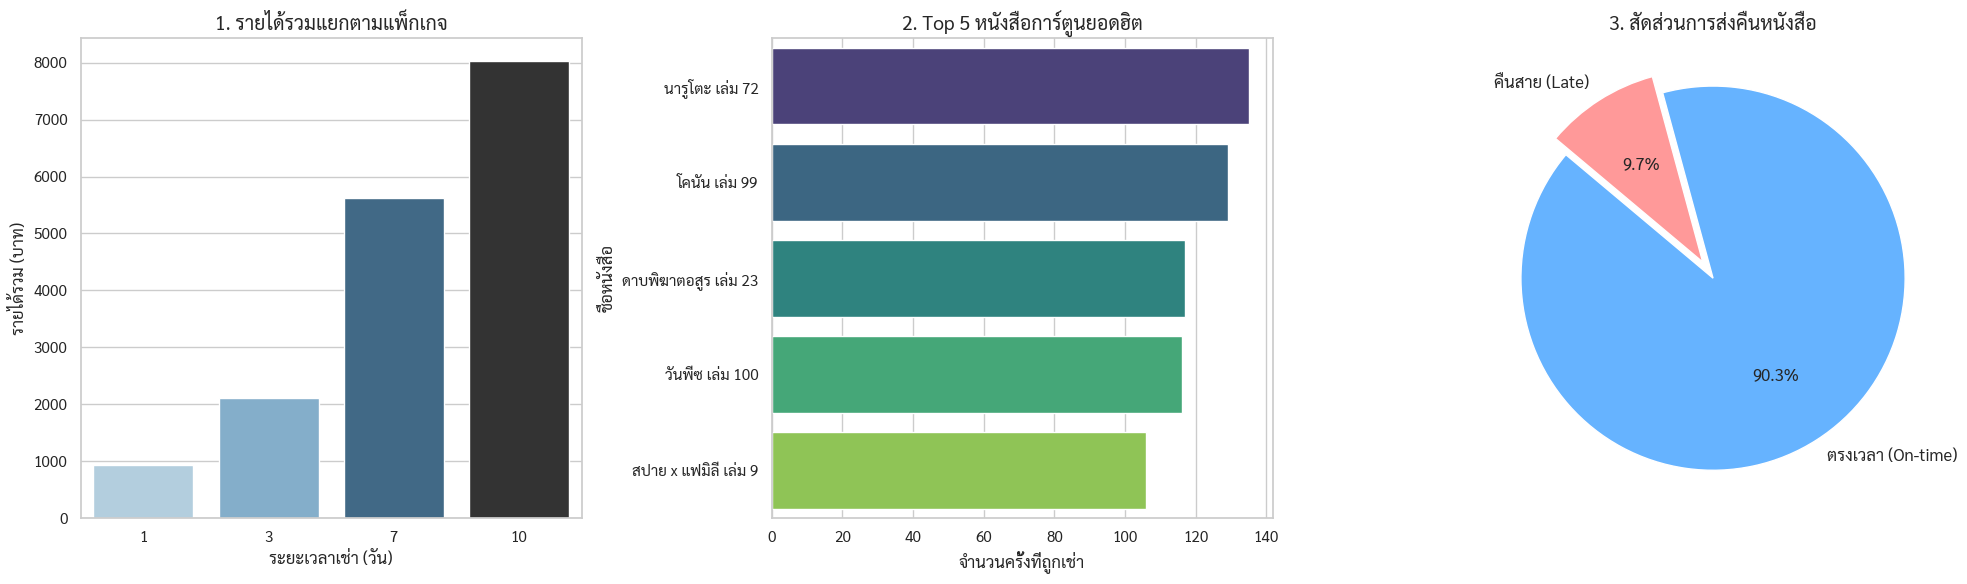

In [ ]:
import os
import random
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# บังคับวาดภาพและแสดงบน Colab/Jupyter ทันที
%matplotlib inline

# ล็อกค่า Seed ให้ผลลัพธ์การสุ่มคงที่
random.seed(42)

# =====================================================================
# 1. จัดการ DB SQLite
# =====================================================================
if os.path.exists("comic_pos.db"):
    try:
        os.remove("comic_pos.db")
    except Exception:
        pass

conn = sqlite3.connect("comic_pos.db")
cursor = conn.cursor()

cursor.execute("""
    CREATE TABLE IF NOT EXISTS receipts (
        order_id TEXT PRIMARY KEY,
        customer_id TEXT,
        days_rented INTEGER,
        days_late INTEGER,
        grand_total REAL
    )
""")
cursor.execute("""
    CREATE TABLE IF NOT EXISTS receipt_items (
        order_id TEXT,
        book_isbn TEXT
    )
""")
cursor.execute("""
    CREATE TABLE IF NOT EXISTS books (
        book_isbn TEXT PRIMARY KEY,
        title TEXT
    )
""")
conn.commit()


# =====================================================================
# 2. ฟังก์ชันดึงค่า + แก้ไขปัญหา book_stock ว่างเปล่า
# =====================================================================
def get_val(obj, key_names, default_val=""):
    if isinstance(obj, dict):
        for k in key_names:
            if k in obj:
                return obj[k]
        return default_val
    for k in key_names:
        if hasattr(obj, k):
            val = getattr(obj, k)
            return val() if callable(val) else val
    return default_val


def calculate_rental_price(books, rent_days):
    total = 0
    for b in books:
        price = get_val(b, ["price", "rental_price", "cost"], 50)
        try:
            price = float(price)
        except (ValueError, TypeError):
            price = 50.0
        total += price * 0.10 * rent_days
    return total


# =====================================================================
# ส่วนที่ 4 — จำลอง "ลูกค้า 1 คนเดินเข้าร้าน" แบบ step-by-step
# =====================================================================
order_counter = 1


def simulate_customer_visit(customer_data, available_books):
    global order_counter

    # ดักป้องกันถ้าลิสต์หนังสือว่างเปล่า ให้เติมหนังสือสำรองทันที
    if not available_books:
        available_books = [
            {
                "book_isbn": "B01",
                "isbn": "B01",
                "title": "วันพีซ เล่ม 100",
                "price": 50,
            },
            {
                "book_isbn": "B02",
                "isbn": "B02",
                "title": "นารูโตะ เล่ม 72",
                "price": 50,
            },
            {
                "book_isbn": "B03",
                "isbn": "B03",
                "title": "โคนัน เล่ม 99",
                "price": 50,
            },
            {
                "book_isbn": "B04",
                "isbn": "B04",
                "title": "ดาบพิฆาตอสูร เล่ม 23",
                "price": 60,
            },
            {
                "book_isbn": "B05",
                "isbn": "B05",
                "title": "สปาย x แฟมิลี เล่ม 9",
                "price": 60,
            },
        ]

    cust_name = get_val(customer_data, ["name", "customer_name"], "ลูกค้า")
    cust_id = get_val(
        customer_data, ["customer_id", "id", "code"], f"C{order_counter:03d}"
    )

    # 1. ทักทายลูกค้า
    print(f"🔔 [ระบบ] ต้อนรับคุณ {cust_name} เข้าสู่ร้านเช่าหนังสือ!")

    # 2. เลือกระยะเวลาเช่า
    rent_days = random.choice([1, 3, 7, 10])
    print(f"   -> ลูกค้าแจ้งความประสงค์เช่าหนังสือเป็นเวลา {rent_days} วัน")

    # 3. เลือกหนังสือ (จะไม่พังแล้ว เพราะดักจับ available_books ไม่ให้เป็น 0)
    sample_size = min(3, len(available_books))
    selected_books = random.sample(
        available_books, k=random.randint(1, sample_size)
    )
    print(f"   -> ลูกค้าหยิบหนังสือมาทั้งหมด {len(selected_books)} เล่ม")

    # 4. คำนวณราคา
    total_amount = calculate_rental_price(selected_books, rent_days)

    # 5. สุ่มวันคืนสาย และบันทึกลง SQLite
    days_late = random.choice([0, 0, 0, 1, 2]) if random.random() < 0.25 else 0
    order_id = f"REC{order_counter:05d}"

    print(
        f"   🧾 [ออกใบเสร็จ {order_id}] ยอดรวม: {total_amount:.2f} บาท"
        f" (คืนสาย {days_late} วัน)\n"
    )

    cursor.execute(
        "INSERT INTO receipts VALUES (?, ?, ?, ?, ?)",
        (order_id, str(cust_id), rent_days, days_late, total_amount),
    )

    for idx, b in enumerate(selected_books, start=1):
        isbn = str(
            get_val(
                b,
                ["book_isbn", "isbn", "id", "code"],
                f"B{idx:02d}_{random.randint(100,999)}",
            )
        )
        title = str(
            get_val(b, ["title", "name", "book_name"], f"หนังสือการ์ตูน {isbn}")
        )

        cursor.execute(
            "INSERT OR REPLACE INTO books VALUES (?, ?)", (isbn, title)
        )
        cursor.execute(
            "INSERT INTO receipt_items VALUES (?, ?)", (order_id, isbn)
        )

    conn.commit()
    order_counter += 1


print("--- ทดสอบส่วนที่ 4 (ลูกค้า 1 คน) ---")

# ดึงข้อมูลจาก BookSearch ของเพื่อน หรือใช้ Fallback List
url_csv = "https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv"
try:
    search_engine = BookSearch(url_csv)
    book_stock = search_engine.catalog
except Exception:
    book_stock = []

try:
    dummy_customer_1 = Customer("C001", "สมชาย", points=120)
except Exception:

    class DummyCust:

        def __init__(self):
            self.name = "สมชาย"
            self.customer_id = "C001"

    dummy_customer_1 = DummyCust()

simulate_customer_visit(dummy_customer_1, book_stock)


# =====================================================================
# ส่วนที่ 5 — จำลองลูกค้าหลายคนเดินเข้าร้านต่อเนื่องกัน
# =====================================================================
print("\n--- ทดสอบส่วนที่ 5 (จำลองลูกค้าหลายคนต่อเนื่องผ่าน Loop) ---")

try:
    customer_queue = [
        Customer("C002", "สมหญิง", points=550),
        Customer("C003", "มานี", points=10),
        Customer("C004", "ปิติ", points=220),
    ]
except Exception:
    customer_queue = [dummy_customer_1, dummy_customer_1, dummy_customer_1]

for index, cust in enumerate(customer_queue, start=1):
    print(f"=== 🚶‍♂️ คิวที่ {index} เดินเข้าร้าน ===")
    simulate_customer_visit(cust, book_stock)


# =====================================================================
# สุ่มวนจนครบ 300 ออเดอร์ เพื่อให้ข้อมูลแน่นสำหรับการแสดงผลกราฟ
# =====================================================================
all_test_customers = [dummy_customer_1] + customer_queue
while order_counter <= 300:
    random_cust = random.choice(all_test_customers)
    simulate_customer_visit(random_cust, book_stock)


# =====================================================================
# ส่วนแสดงผลกราฟ 3 รูป ล่างสุด
# =====================================================================
sql_q1 = pd.read_sql_query(
    """
    SELECT days_rented AS 'ระยะเวลาเช่า (วัน)',
           SUM(grand_total) AS 'รายได้รวม (บาท)'
    FROM receipts
    GROUP BY days_rented
    ORDER BY SUM(grand_total) DESC
""",
    conn,
)

sql_q2 = pd.read_sql_query(
    """
    SELECT b.title AS 'ชื่อหนังสือ',
           COUNT(ri.order_id) AS 'จำนวนครั้งที่ถูกเช่า'
    FROM receipt_items ri
    JOIN books b ON ri.book_isbn = b.book_isbn
    GROUP BY b.book_isbn, b.title
    ORDER BY COUNT(ri.order_id) DESC
    LIMIT 5
""",
    conn,
)

df_receipts = pd.read_sql_query("SELECT * FROM receipts", conn)
conn.close()

# วาดกราฟ
sns.set_theme(style="whitegrid", font="Sarabun")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    ax=axes[0],
    data=sql_q1,
    x="ระยะเวลาเช่า (วัน)",
    y="รายได้รวม (บาท)",
    hue="ระยะเวลาเช่า (วัน)",
    palette="Blues_d",
    legend=False,
)
axes[0].set_title("1. รายได้รวมแยกตามแพ็กเกจ", fontsize=14, fontweight="bold")

sns.barplot(
    ax=axes[1],
    data=sql_q2,
    x="จำนวนครั้งที่ถูกเช่า",
    y="ชื่อหนังสือ",
    hue="ชื่อหนังสือ",
    palette="viridis",
    legend=False,
)
axes[1].set_title(
    "2. Top 5 หนังสือการ์ตูนยอดฮิต", fontsize=14, fontweight="bold"
)

df_receipts["return_status"] = df_receipts["days_late"].apply(
    lambda x: "คืนสาย (Late)" if x > 0 else "ตรงเวลา (On-time)"
)
status_counts = df_receipts["return_status"].value_counts()
axes[2].pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff9999"],
    startangle=140,
    explode=(0, 0.1),
    textprops={"fontsize": 12},
)
axes[2].set_title("3. สัดส่วนการส่งคืนหนังสือ", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()